<a href="https://colab.research.google.com/github/shivanshu1512/PyTorch_CV_Animals/blob/main/animals_classification_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## So we are going to pratice on an animal dataset  for clarity how pytorch datasets works

In [1]:
from google.colab import drive

# Mount your Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
from pathlib import Path

# Updated path matching your screenshot folder
DRIVE_ZIP_PATH = Path("/content/drive/MyDrive/project_1_data/animals.zip")

# Target local directory on the Colab server
LOCAL_DATA_DIR = Path("/content/data/animals")

# Unzip step
if LOCAL_DATA_DIR.is_dir():
    print(f"[INFO] {LOCAL_DATA_DIR} already exists. Ready to use.")
else:
    if not DRIVE_ZIP_PATH.exists():
        print(f"[ERROR] Could not find the zip file at: {DRIVE_ZIP_PATH}")
        print("Please double check that the file name matches exactly (including lowercase/uppercase).")
    else:
        print(f"[INFO] Creating local directory at: {LOCAL_DATA_DIR}")
        LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

        print(f"[INFO] Extracting {DRIVE_ZIP_PATH.name}...")
        with zipfile.ZipFile(DRIVE_ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(LOCAL_DATA_DIR)
        print("[INFO] Extraction complete!")

[INFO] Creating local directory at: /content/data/animals
[INFO] Extracting animals.zip...
[INFO] Extraction complete!


## Data Preperation


In [3]:
from pathlib import Path

# Explicitly define the variable that Colab says is missing
image_path = Path("/content/data/animals")


import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory

  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [4]:
walk_through_dir(image_path)

There are 1 directories and 0 images in '/content/data/animals'.
There are 90 directories and 0 images in '/content/data/animals/animals'.
There are 0 directories and 60 images in '/content/data/animals/animals/duck'.
There are 0 directories and 60 images in '/content/data/animals/animals/woodpecker'.
There are 0 directories and 60 images in '/content/data/animals/animals/lobster'.
There are 0 directories and 60 images in '/content/data/animals/animals/pigeon'.
There are 0 directories and 60 images in '/content/data/animals/animals/otter'.
There are 0 directories and 60 images in '/content/data/animals/animals/goldfish'.
There are 0 directories and 60 images in '/content/data/animals/animals/chimpanzee'.
There are 0 directories and 60 images in '/content/data/animals/animals/coyote'.
There are 0 directories and 60 images in '/content/data/animals/animals/seahorse'.
There are 0 directories and 60 images in '/content/data/animals/animals/possum'.
There are 0 directories and 60 images in 

In [5]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir


(PosixPath('/content/data/animals/train'),
 PosixPath('/content/data/animals/test'))

In [6]:
### Visualizing the data

Random image path: /content/data/animals/animals/snake/0dd9e55a78.jpg
Image class: snake
Image height: 168
Image width: 300


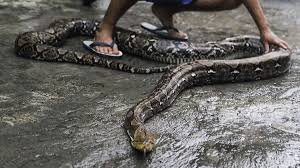

In [7]:
import random
from PIL import Image

# Set seed
random.seed(42) # <- try changing this and see what happens

# 1. Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

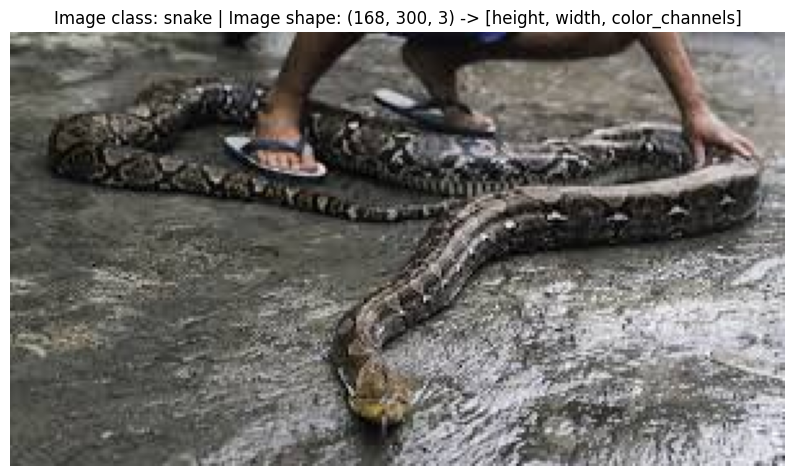

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

##  Transforming the data

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [10]:
# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

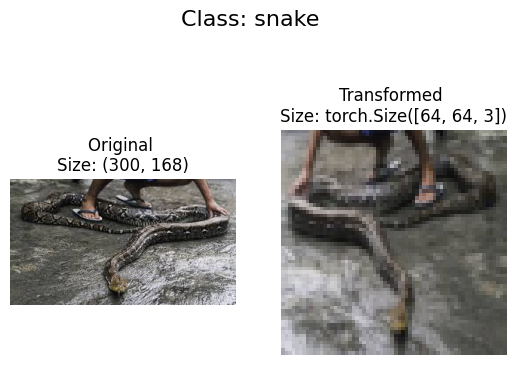

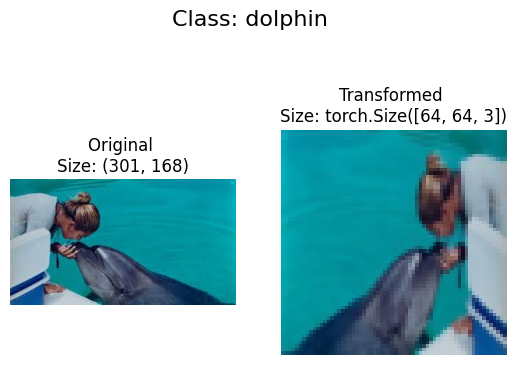

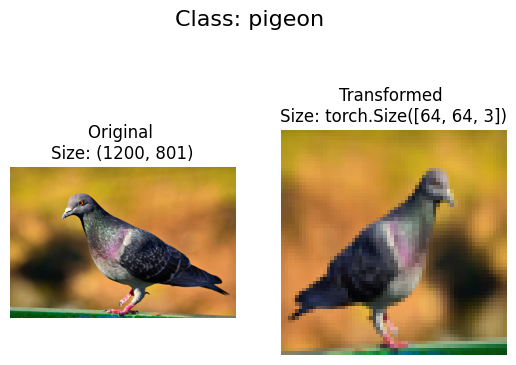

In [11]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths.
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list,
                        transform=data_transform,
                        n=3)

In [12]:
from pathlib import Path

# Change this to point to the actual folder containing the 90 animal subdirectories
train_dir = Path("/content/data/animals/animals")
test_dir = Path("/content/data/animals/animals")

# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 5400
    Root location: /content/data/animals/animals
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 5400
    Root location: /content/data/animals/animals
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [13]:
# Get class names as a list
class_names = train_data.classes
class_names

['antelope',
 'badger',
 'bat',
 'bear',
 'bee',
 'beetle',
 'bison',
 'boar',
 'butterfly',
 'cat',
 'caterpillar',
 'chimpanzee',
 'cockroach',
 'cow',
 'coyote',
 'crab',
 'crow',
 'deer',
 'dog',
 'dolphin',
 'donkey',
 'dragonfly',
 'duck',
 'eagle',
 'elephant',
 'flamingo',
 'fly',
 'fox',
 'goat',
 'goldfish',
 'goose',
 'gorilla',
 'grasshopper',
 'hamster',
 'hare',
 'hedgehog',
 'hippopotamus',
 'hornbill',
 'horse',
 'hummingbird',
 'hyena',
 'jellyfish',
 'kangaroo',
 'koala',
 'ladybugs',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'mosquito',
 'moth',
 'mouse',
 'octopus',
 'okapi',
 'orangutan',
 'otter',
 'owl',
 'ox',
 'oyster',
 'panda',
 'parrot',
 'pelecaniformes',
 'penguin',
 'pig',
 'pigeon',
 'porcupine',
 'possum',
 'raccoon',
 'rat',
 'reindeer',
 'rhinoceros',
 'sandpiper',
 'seahorse',
 'seal',
 'shark',
 'sheep',
 'snake',
 'sparrow',
 'squid',
 'squirrel',
 'starfish',
 'swan',
 'tiger',
 'turkey',
 'turtle',
 'whale',
 'wolf',
 'wombat',
 'woodpecker',


In [14]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'antelope': 0,
 'badger': 1,
 'bat': 2,
 'bear': 3,
 'bee': 4,
 'beetle': 5,
 'bison': 6,
 'boar': 7,
 'butterfly': 8,
 'cat': 9,
 'caterpillar': 10,
 'chimpanzee': 11,
 'cockroach': 12,
 'cow': 13,
 'coyote': 14,
 'crab': 15,
 'crow': 16,
 'deer': 17,
 'dog': 18,
 'dolphin': 19,
 'donkey': 20,
 'dragonfly': 21,
 'duck': 22,
 'eagle': 23,
 'elephant': 24,
 'flamingo': 25,
 'fly': 26,
 'fox': 27,
 'goat': 28,
 'goldfish': 29,
 'goose': 30,
 'gorilla': 31,
 'grasshopper': 32,
 'hamster': 33,
 'hare': 34,
 'hedgehog': 35,
 'hippopotamus': 36,
 'hornbill': 37,
 'horse': 38,
 'hummingbird': 39,
 'hyena': 40,
 'jellyfish': 41,
 'kangaroo': 42,
 'koala': 43,
 'ladybugs': 44,
 'leopard': 45,
 'lion': 46,
 'lizard': 47,
 'lobster': 48,
 'mosquito': 49,
 'moth': 50,
 'mouse': 51,
 'octopus': 52,
 'okapi': 53,
 'orangutan': 54,
 'otter': 55,
 'owl': 56,
 'ox': 57,
 'oyster': 58,
 'panda': 59,
 'parrot': 60,
 'pelecaniformes': 61,
 'penguin': 62,
 'pig': 63,
 'pigeon': 64,
 'porcupine': 65,
 'pos

In [15]:
len(train_data),len(test_data)

(5400, 5400)

In [16]:
# import torch
# from torchvision import transforms

IMAGE_SIZE = (64, 64)

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Testing transformations
test_transform = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [17]:
import copy
from pathlib import Path
from torchvision import datasets
from torch.utils.data import random_split

# Point to your actual base directory containing the 90 animal folders
data_dir = Path("/content/data/animals/animals")

# 1. Load everything into a single dataset pool
full_dataset = datasets.ImageFolder(root=data_dir)

# 2. Calculate 80% train and 20% test subset lengths
train_length = int(0.8 * len(full_dataset))
test_length = len(full_dataset) - train_length

# 3. Mathematically split the dataset so there is NO image overlap
train_subset, test_subset = random_split(full_dataset, [train_length, test_length])

# 4. Assign the different transforms to each subset safely
# We use copy.deepcopy to ensure changing one transform doesn't affect the other
train_data = copy.deepcopy(train_subset)
train_data.dataset.transform = train_transform

test_data = copy.deepcopy(test_subset)
test_data.dataset.transform = test_transform

In [18]:
len(train_data),len(test_data)

(4320, 1080)

In [19]:
# now it good differnce between test and train is good

In [20]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[-0.5424, -0.7650, -0.7137,  ..., -0.2856,  0.3138,  0.4851],
         [-0.2342, -0.1999, -0.2684,  ...,  0.2282,  0.5364,  0.6392],
         [ 0.2967,  0.5193,  0.4679,  ...,  0.2967,  0.2282,  0.2453],
         ...,
         [ 0.6392,  0.6563,  0.5193,  ...,  0.0398,  0.3823,  0.4337],
         [-0.1828, -0.0972,  0.1597,  ...,  0.2453,  0.4166,  0.3823],
         [ 0.3481,  0.4851,  0.4679,  ..., -0.0287,  0.4337,  0.6049]],

        [[-0.8102, -1.0378, -0.9678,  ..., -0.5126,  0.1702,  0.3452],
         [-0.3725, -0.4426, -0.5301,  ..., -0.0049,  0.3452,  0.4678],
         [ 0.3102,  0.3452,  0.2577,  ...,  0.0476, -0.0049, -0.0049],
         ...,
         [ 0.5378,  0.5203,  0.3277,  ..., -0.2325,  0.0826,  0.0826],
         [-0.5651, -0.4076, -0.0399,  ..., -0.0399,  0.1352,  0.0651],
         [-0.0224,  0.2052,  0.2927,  ..., -0.3550,  0.1176,  0.3102]],

        [[-1.0201, -1.2467, -1.1770,  ..., -0.7064, -0.0441,  0.1128],
         [-0.6890, -0.7064, -0.

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


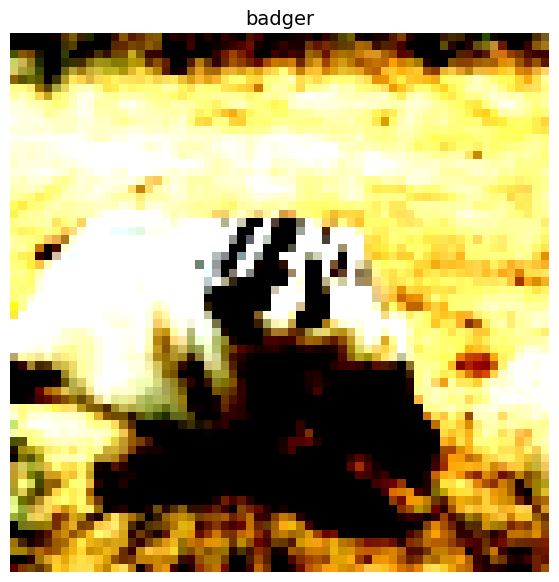

In [21]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes (before and after permute)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);

In [22]:
# What permute(1, 2, 0) is doing
# When you pass (1, 2, 0) into permute(), you are telling PyTorch to shift the entire structural axes to a new order:

# Put Position 1 (Height) first.

# Put Position 2 (Width) second.

# Put Position 0 (Color Channels) last.

# Because of this instructions, the shape completely shifts:

# The dimension of size 64 (Height) moves to the front.

# The dimension of size 64 (Width) stays in the middle.

# The dimension of size 3 (Channels) moves to the back.

In [23]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1, # how many samples per batch?
                              num_workers=1, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False) # don't usually need to shuffle testing data

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bf10be87b30>,
 <torch.utils.data.dataloader.DataLoader at 0x7bf10c1394f0>)

In [24]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


In [25]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [26]:
# Instance of torchvision.datasets.ImageFolder()
train_data.dataset.classes, train_data.dataset.class_to_idx

(['antelope',
  'badger',
  'bat',
  'bear',
  'bee',
  'beetle',
  'bison',
  'boar',
  'butterfly',
  'cat',
  'caterpillar',
  'chimpanzee',
  'cockroach',
  'cow',
  'coyote',
  'crab',
  'crow',
  'deer',
  'dog',
  'dolphin',
  'donkey',
  'dragonfly',
  'duck',
  'eagle',
  'elephant',
  'flamingo',
  'fly',
  'fox',
  'goat',
  'goldfish',
  'goose',
  'gorilla',
  'grasshopper',
  'hamster',
  'hare',
  'hedgehog',
  'hippopotamus',
  'hornbill',
  'horse',
  'hummingbird',
  'hyena',
  'jellyfish',
  'kangaroo',
  'koala',
  'ladybugs',
  'leopard',
  'lion',
  'lizard',
  'lobster',
  'mosquito',
  'moth',
  'mouse',
  'octopus',
  'okapi',
  'orangutan',
  'otter',
  'owl',
  'ox',
  'oyster',
  'panda',
  'parrot',
  'pelecaniformes',
  'penguin',
  'pig',
  'pigeon',
  'porcupine',
  'possum',
  'raccoon',
  'rat',
  'reindeer',
  'rhinoceros',
  'sandpiper',
  'seahorse',
  'seal',
  'shark',
  'sheep',
  'snake',
  'sparrow',
  'squid',
  'squirrel',
  'starfish',
  'sw

In [27]:
# Setup path for target directory
target_directory = train_dir
print(f"Target directory: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(image_path / "animals"))])
print(f"Class names found: {class_names_found}")

Target directory: /content/data/animals/animals
Class names found: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']


In [28]:
# Make function to find classes in target directory
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.

    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load classnames from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))

    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """
    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if class names not found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}.")

    # 3. Create a dictionary of index labels (computers prefer numerical rather than string labels)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [29]:
find_classes(train_dir)

(['antelope',
  'badger',
  'bat',
  'bear',
  'bee',
  'beetle',
  'bison',
  'boar',
  'butterfly',
  'cat',
  'caterpillar',
  'chimpanzee',
  'cockroach',
  'cow',
  'coyote',
  'crab',
  'crow',
  'deer',
  'dog',
  'dolphin',
  'donkey',
  'dragonfly',
  'duck',
  'eagle',
  'elephant',
  'flamingo',
  'fly',
  'fox',
  'goat',
  'goldfish',
  'goose',
  'gorilla',
  'grasshopper',
  'hamster',
  'hare',
  'hedgehog',
  'hippopotamus',
  'hornbill',
  'horse',
  'hummingbird',
  'hyena',
  'jellyfish',
  'kangaroo',
  'koala',
  'ladybugs',
  'leopard',
  'lion',
  'lizard',
  'lobster',
  'mosquito',
  'moth',
  'mouse',
  'octopus',
  'okapi',
  'orangutan',
  'otter',
  'owl',
  'ox',
  'oyster',
  'panda',
  'parrot',
  'pelecaniformes',
  'penguin',
  'pig',
  'pigeon',
  'porcupine',
  'possum',
  'raccoon',
  'rat',
  'reindeer',
  'rhinoceros',
  'sandpiper',
  'seahorse',
  'seal',
  'shark',
  'sheep',
  'snake',
  'sparrow',
  'squid',
  'squirrel',
  'starfish',
  'sw

## Create a custom Dataset to replicate ImageFolder

In [30]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:

        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg")) # note: you'd have to update this if you've got .png's or .jpeg's
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path)

    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)

    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

In [31]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# Don't augment test data, only reshape
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [32]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7bf10be65400>,
 <__main__.ImageFolderCustom at 0x7bf24a328ce0>)

In [33]:
len(train_data_custom), len(test_data_custom)

(5400, 5400)

In [34]:
import pathlib
import torch
from torch.utils.data import Dataset
from PIL import Image
from typing import Tuple, List

class ImageFolderCustom(Dataset):
    # 1. Add mode and split_ratio to the initialization parameters
    def __init__(self, targ_dir: str, transform=None, mode: str = "train", split_ratio: float = 0.8) -> None:

        # Setup transforms
        self.transform = transform

        # Get ALL raw image paths sorted so the order is identical across instances
        all_paths = sorted(list(pathlib.Path(targ_dir).glob("*/*.jpg")))

        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

        # 2. Filter paths based on train/test mode to ensure no overlapping data
        self.paths = []

        for class_name in self.classes:
            # Gather all images belonging to this specific animal class
            class_specific_paths = [p for p in all_paths if p.parent.name == class_name]

            # Calculate the split boundary (e.g., 60 images * 0.8 = 48 images)
            split_boundary = int(len(class_specific_paths) * split_ratio)

            # Distribute files based on the requested mode
            if mode == "train":
                self.paths.extend(class_specific_paths[:split_boundary])
            elif mode == "test":
                self.paths.extend(class_specific_paths[split_boundary:])

    # 3. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)

    # 4. __len__() returns the size of the SPLIT subset, not the full pool
    def __len__(self) -> int:
        return len(self.paths)

    # 5. __getitem__() remains clean and handles only the subset data
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [35]:
# Create custom training dataset (gets 80% of data = 4,320 images)
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms,
                                      mode="train",
                                      split_ratio=0.8)

# Create custom testing dataset (gets remaining 20% of data = 1,080 images)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms,
                                     mode="test",
                                     split_ratio=0.8)

# Check lengths
print(f"Train size: {len(train_data_custom)}, Test size: {len(test_data_custom)}")

Train size: 4320, Test size: 1080


In [36]:
# Check for equality amongst our custom Dataset and ImageFolder Dataset
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))

# REMOVED .dataset from train_data_custom since it holds attributes directly
print(train_data_custom.classes == train_data.dataset.classes)
print(train_data_custom.class_to_idx == train_data.dataset.class_to_idx)

True
True
True


In [37]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

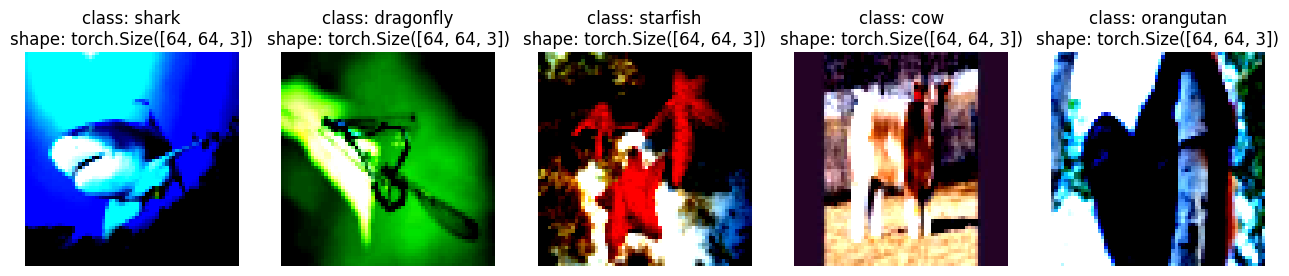

In [38]:
# Display random images from ImageFolder created Dataset
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


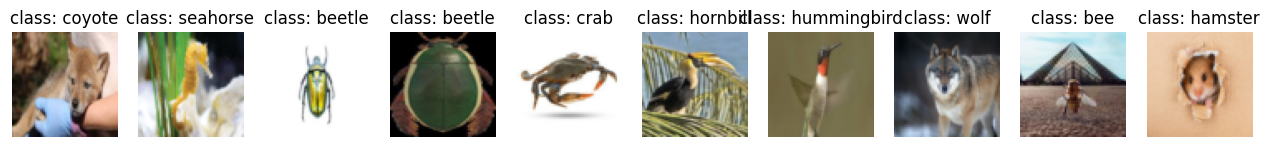

In [39]:
# Display random images from ImageFolderCustom Dataset
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=None) # Try setting the seed for reproducible images

In [40]:
# Turn train and test custom Dataset's into DataLoader's
from torch.utils.data import DataLoader
train_dataloader_custom = DataLoader(dataset=train_data_custom, # use custom created train Dataset
                                     batch_size=1, # how many samples per batch?
                                     num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                                     shuffle=True) # shuffle the data?

test_dataloader_custom = DataLoader(dataset=test_data_custom, # use custom created test Dataset
                                    batch_size=1,
                                    num_workers=0,
                                    shuffle=False) # don't usually need to shuffle testing data

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7bf10c121f70>,
 <torch.utils.data.dataloader.DataLoader at 0x7bf10aec3fb0>)

In [41]:
# Get image and label from custom DataLoader
img_custom, label_custom = next(iter(train_dataloader_custom))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


## Data augementation

In [42]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), # how intense
    transforms.ToTensor() # use ToTensor() last to get everything between 0 & 1
])

# Don't need to perform augmentation on the test data
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

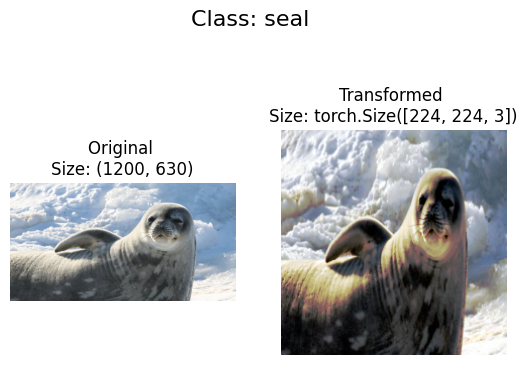

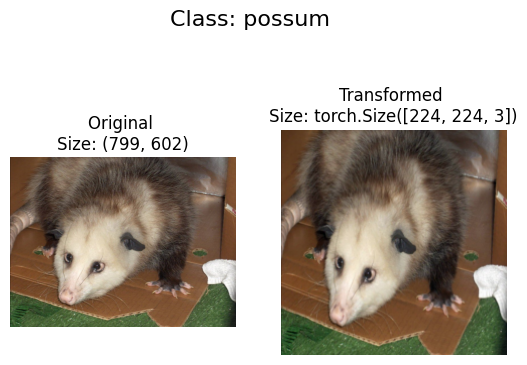

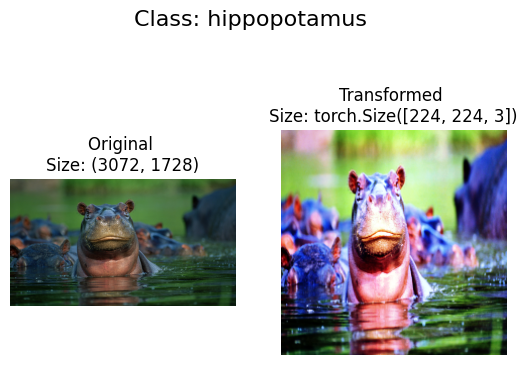

In [43]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Plot random images
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transforms,
    n=3,
    seed=None
)

## Tiny VGG

In [44]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [45]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

# 2. Turn data into DataLoaders
import os
from torch.utils.data import DataLoader

# Setup batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
print(f"Creating DataLoader's with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create DataLoader's
train_dataloader_simple = DataLoader(train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_simple, test_dataloader_simple

Creating DataLoader's with batch size 32 and 2 workers.


(<torch.utils.data.dataloader.DataLoader at 0x7bf10ac48c80>,
 <torch.utils.data.dataloader.DataLoader at 0x7bf10ae76b70>)

In [46]:
import torch
from torch import nn

class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.dataset.classes)); ## Look closely at the very last line of your code block:
# Python
# output_shape=len(train_data.classes)
# Remember that because we used random_split earlier, train_data is a Subset wrapper. If you run your code as-is, it might throw another AttributeError: 'Subset' object has no attribute 'classes'.

# To prevent that next error from happening, make sure to change that specific line to access the classes through the underlying dataset:
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=90, bias=True)
  )
)

In [47]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader_simple))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single)

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[ 0.0433,  0.0567,  0.0275, -0.0311, -0.0426,  0.0581, -0.0739,  0.0858,
          0.0023,  0.0611, -0.0264, -0.0293, -0.0083, -0.0509,  0.0732,  0.0155,
          0.0104,  0.0403,  0.0010,  0.0460, -0.0251, -0.0196,  0.0277, -0.0061,
          0.0105,  0.0658,  0.0248,  0.0694,  0.0203, -0.0437, -0.0086,  0.0940,
          0.0047, -0.0737, -0.0166,  0.0046, -0.0366, -0.0599,  0.0171,  0.0054,
          0.0078, -0.0459,  0.0140,  0.0540, -0.0330, -0.0066,  0.0503,  0.0664,
          0.0437,  0.0346, -0.0211, -0.0474, -0.0411,  0.0436,  0.0057, -0.0395,
          0.0106,  0.0493,  0.0131,  0.0234, -0.0252, -0.0045, -0.0302, -0.0387,
          0.0014,  0.0566, -0.0127,  0.0149, -0.0047,  0.0400,  0.0180, -0.0269,
         -0.0369,  0.0280,  0.0348,  0.0005,  0.0744,  0.0089, -0.0119, -0.0365,
         -0.0090, -0.0207,  0.0008,  0.0539, -0.0286, -0.0126,  0.0029,  0.0030,
         -0.0095,  0.0210]])

Output predictio

In [48]:
# Install torchinfo if it's not available, import it if it is
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64]) # do a test pass through of an example input size

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 90]                   --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

In [49]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [50]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [51]:
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [57]:
import torch

# Define device agnostic code (use GPU if available, otherwise default to CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Move your model instance to this device explicitly
model_0 = model_0.to(device)

Using device: cuda


In [58]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
# Recreate an instance of TinyVGG and instantly push it to the GPU/CPU device
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.dataset.classes)).to(device) # <--- ADD .to(device) HERE

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 4.4318 | train_acc: 0.0172 | test_loss: 4.2240 | test_acc: 0.0374
Epoch: 2 | train_loss: 4.1443 | train_acc: 0.0636 | test_loss: 3.8830 | test_acc: 0.1050
Epoch: 3 | train_loss: 3.7713 | train_acc: 0.1280 | test_loss: 3.3521 | test_acc: 0.2302
Epoch: 4 | train_loss: 3.2044 | train_acc: 0.2429 | test_loss: 2.5656 | test_acc: 0.3970
Epoch: 5 | train_loss: 2.4978 | train_acc: 0.4048 | test_loss: 1.8032 | test_acc: 0.5836
Total training time: 445.221 seconds


In [59]:
# Check the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [60]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

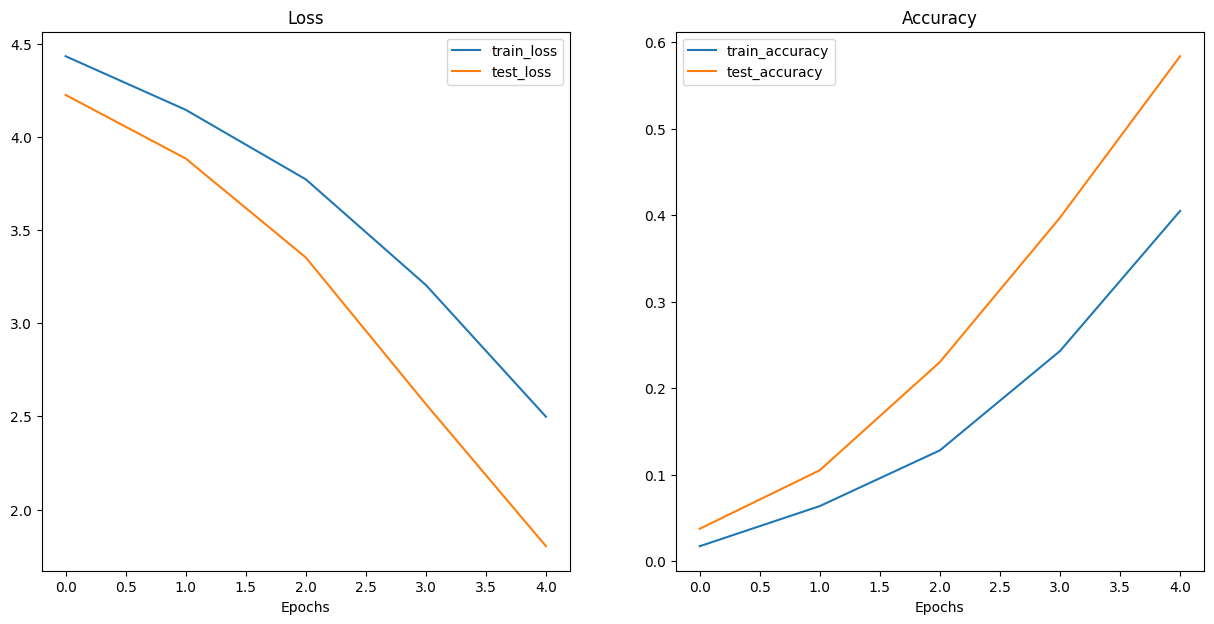

In [61]:
plot_loss_curves(model_0_results)

1. The Loss Plot (Left)What it shows: Loss measures how wrong your model's predictions are. Both your train_loss (blue) and test_loss (orange) are in a steep, steady decline.What it indicates: A decreasing loss curve means the network's weights are adjusting correctly via gradient descent. Because the curves are dropping rapidly and haven't flattened out yet, it indicates that the model is still actively learning and could benefit from training for even more epochs.

2. The Accuracy Plot (Right)What it shows: Accuracy measures the percentage of images the model correctly guesses out of the 90 animal species. Both train_accuracy and test_accuracy are climbing nicely, with the test accuracy reaching nearly 60% ($0.6$) by epoch 4.What it indicates: Considering that a random guess out of 90 classes would yield an accuracy of only about $1.1\%$, hitting nearly 60% in just 5 epochs is excellent. Your model is picking up real, identifiable visual features from the animal dataset.

3. The Relationship Between the Curves (No Overfitting)The most important thing these plots tell you is that your model is not overfitting.Why? In an overfitted model, you would see the training metrics keep improving, but the test loss would start climbing back up and test accuracy would freeze or drop (meaning it memorized the training images but failed on the test images).Your case: Your test metrics (orange lines) are moving tightly alongside your training metrics. In fact, your test accuracy is slightly higher than your training accuracy. This can occasionally happen early on due to data augmentation making the training set artificially harder to learn than the clean test set. It proves that the programmatic train/test split we set up earlier is working perfectly.

## So we try to improve the accuracy

In [62]:
# Create training transform with TrivialAugment
train_transform_trivial_augment = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

# Create testing transform (no data augmentation)
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [63]:
# Turn image folders into Datasets
train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform_trivial_augment)
test_data_simple = datasets.ImageFolder(test_dir, transform=test_transform)

train_data_augmented, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 5400
     Root location: /content/data/animals/animals
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 5400
     Root location: /content/data/animals/animals
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [64]:
# Turn Datasets into DataLoader's
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bf10ac71f70>,
 <torch.utils.data.dataloader.DataLoader at 0x7bf10c1394f0>)

In [65]:
# Create model_1 and send it to the target device
torch.manual_seed(42)
model_1 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=90, bias=True)
  )
)

In [66]:
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 4.4804 | train_acc: 0.0148 | test_loss: 4.4092 | test_acc: 0.0266
Epoch: 2 | train_loss: 4.3827 | train_acc: 0.0235 | test_loss: 4.2351 | test_acc: 0.0486
Epoch: 3 | train_loss: 4.2808 | train_acc: 0.0462 | test_loss: 4.1307 | test_acc: 0.0662
Epoch: 4 | train_loss: 4.2163 | train_acc: 0.0565 | test_loss: 3.9755 | test_acc: 0.1035
Epoch: 5 | train_loss: 4.1216 | train_acc: 0.0730 | test_loss: 3.7818 | test_acc: 0.1399
Total training time: 453.392 seconds


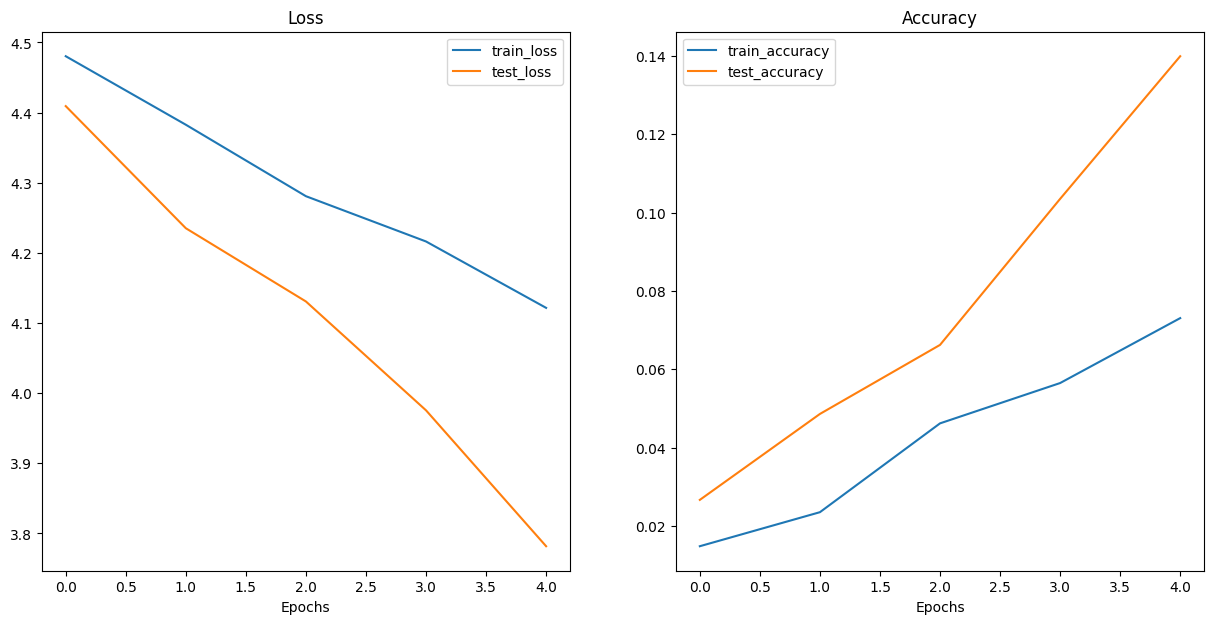

In [67]:
plot_loss_curves(model_1_results)

## Compare model results

In [68]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,4.431786,0.017197,4.223999,0.037352
1,4.144266,0.063609,3.883044,0.105030
2,3.771270,0.128020,3.352128,0.230153
3,3.204351,0.242850,2.565638,0.397004
4,2.497837,0.404771,1.803175,0.583642


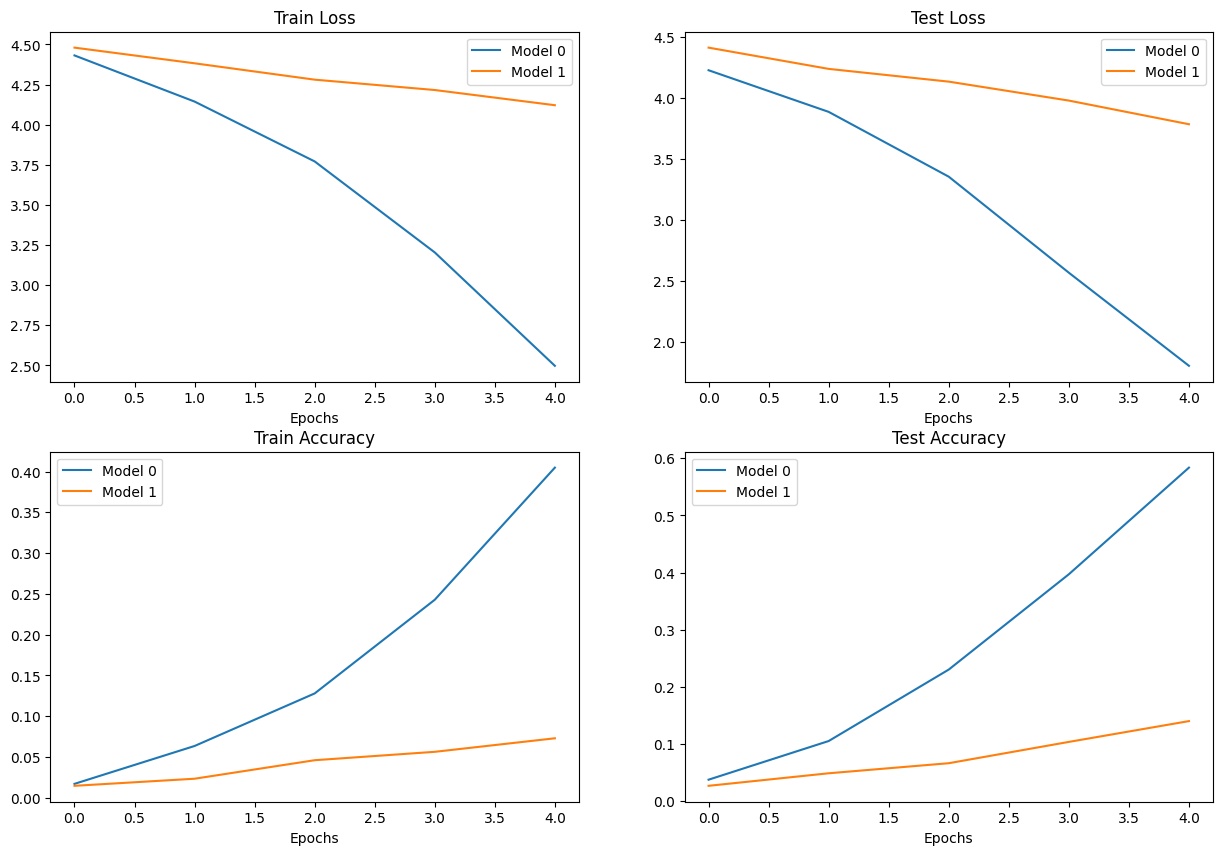

In [69]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

## Make prediction on any image

In [71]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

# Print out image data
print(f"Custom image tensor:\n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")/


SyntaxError: invalid syntax (2279910548.py, line 9)